In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import TargetEncoder
#from category_encoders import TargetEncoder
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import StandardScaler
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import RocCurveDisplay, auc, roc_curve

#Validation section of tutorial
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv("drive/My Drive/Colab Notebooks/TMU_DM_808K_R1.csv") #Add your file path here

Mounted at /content/drive


In [ ]:
data.head()

,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,duration_b_R1_[corticosteroid]_Days,total_b_R1_[corticosteroid]_Records,first_b_R1_[1stlineantidiabetic],first_StartDate_b_R1_[1stlineantidiabetic],first_StopDate_b_R1_[1stlineantidiabetic],last_b_R1_[1stlineantidiabetic],last_StartDate_b_R1_[1stlineantidiabetic],last_StopDate_b_R1_[1stlineantidiabetic],duration_b_R1_[1stlineantidiabetic]_Days,total_b_R1_[1stlineantidiabetic]_Records
0,69,Male,140.0,2010-03-18,26.000000,2010-12-17,3.35,2010-03-06,1.03,2010-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,56,Female,120.0,2011-11-03,24.000000,2011-11-03,4.01,2011-10-04,1.84,2011-10-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,35,Female,100.0,2014-02-21,51.195667,2014-02-21,3.11,2014-02-24,1.26,2014-02-24,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,43,Female,138.0,2013-07-04,67.794421,2013-07-04,2.96,2013-08-02,1.09,2013-08-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49,Male,141.0,2013-03-13,34.000000,2013-01-24,4.06,2013-01-24,1.34,2013-01-24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Checking if there are duplicates in Patients (a patient appears more than once)
data['Patient_ID'].is_unique

False

In [ ]:
data['Patient_ID'].nunique()

171619

There are 171619 patients with some patients having more than one visit

In [ ]:
data.columns

Index(['Age_at_Exam', 'Sex', 'sBP', 'sBP_Date', 'BMI', 'BMI_Date', 'LDL',
       'LDL_Date', 'HDL', 'HDL_Date',
       ...
       'duration_b_R1_[corticosteroid]_Days',
       'total_b_R1_[corticosteroid]_Records',
       'first_b_R1_[1stlineantidiabetic]',
       'first_StartDate_b_R1_[1stlineantidiabetic]',
       'first_StopDate_b_R1_[1stlineantidiabetic]',
       'last_b_R1_[1stlineantidiabetic]',
       'last_StartDate_b_R1_[1stlineantidiabetic]',
       'last_StopDate_b_R1_[1stlineantidiabetic]',
       'duration_b_R1_[1stlineantidiabetic]_Days',
       'total_b_R1_[1stlineantidiabetic]_Records'],
      dtype='object', length=175)

In [ ]:
#Descriptive Statistics for the Dataset
data.describe()

,Age_at_Exam,sBP,BMI,LDL,HDL,A1c,TG,FBS,Total_Cholesterol,Diabetes,...,duration_b_R1_[antihtn]_Days,total_b_R1_[antihtn]_Records,first_b_R1_[corticosteroid],last_b_R1_[corticosteroid],duration_b_R1_[corticosteroid]_Days,total_b_R1_[corticosteroid]_Records,first_b_R1_[1stlineantidiabetic],last_b_R1_[1stlineantidiabetic],duration_b_R1_[1stlineantidiabetic]_Days,total_b_R1_[1stlineantidiabetic]_Records
count,808921.000000,808161.000000,808921.000000,803729.000000,800702.000000,364992.000000,799025.000000,808921.000000,792052.000000,808921.000000,...,219890.000000,414438.000000,187708.0,187708.000000,117632.000000,187708.000000,136067.0,136067.000000,67999.000000,136067.000000
mean,60.661937,129.335292,29.709366,2.835181,1.388132,6.267142,1.517779,5.787540,4.889116,0.289848,...,1875.890959,15.714734,1.0,0.506766,789.851614,2.814925,1.0,0.867433,1489.867292,8.442385
std,14.062109,17.142063,7.049516,0.989493,0.415248,0.974855,0.960199,1.496355,1.156868,0.453692,...,1397.943958,18.011430,0.0,0.499956,1084.925542,4.107221,0.0,0.339107,1081.835607,8.417404
min,18.000000,40.000000,5.080655,0.100000,0.100000,0.530000,0.100000,2.000000,0.760000,0.000000,...,-2065.000000,1.000000,1.0,0.000000,-183.000000,1.000000,1.0,0.000000,0.000000,1.000000
25%,51.000000,119.000000,25.200000,2.100000,1.100000,5.700000,0.920000,4.900000,4.060000,0.000000,...,876.000000,4.000000,1.0,0.000000,14.000000,1.000000,1.0,1.000000,560.000000,3.000000
50%,61.000000,129.000000,28.600000,2.780000,1.320000,6.000000,1.300000,5.400000,4.830000,0.000000,...,1779.000000,10.000000,1.0,1.000000,365.000000,2.000000,1.0,1.000000,1327.000000,6.000000
75%,71.000000,140.000000,32.800000,3.480000,1.610000,6.600000,1.850000,6.100000,5.640000,1.000000,...,2737.000000,20.000000,1.0,1.000000,1270.000000,3.000000,1.0,1.000000,2294.000000,11.000000
max,90.000000,260.000000,240.086698,10.000000,5.000000,17.800000,57.340000,34.100000,20.820000,1.000000,...,42720.000000,229.000000,1.0,1.000000,42391.000000,105.000000,1.0,1.000000,5863.000000,86.000000


Finding the number of patients with or without diabetes

In [ ]:
data['Diabetes'].value_counts()

,count
Diabetes,
0,574457
1,234464


In [ ]:
#Subsetting the dataset to contain only patients with Diabetes
data = data[data['Diabetes'] == 1]

In [ ]:
#Confirming if the subsetting has been done (Datasets for patients diabetes only)
data['Diabetes'].value_counts()

,count
Diabetes,
1,234464


In [ ]:
#Filtering out our interested features and label (DiabeticFootUlcer) into a new dataframe, df
df = data[['Patient_ID','Sex','A1c','FBS', 'duration_b_R1_[corticosteroid]_Days', 'duration_b_R1_[1stlineantidiabetic]_Days', 'duration_b_R1_[2ndline-antidiabetic]_Days'  ,'[DiabeticFootUlcer)']]
df = df.reset_index(drop=True)
df.head()

,Patient_ID,Sex,A1c,FBS,duration_b_R1_[corticosteroid]_Days,duration_b_R1_[1stlineantidiabetic]_Days,duration_b_R1_[2ndline-antidiabetic]_Days,[DiabeticFootUlcer)
0,4001000000256899,Male,6.6,5.8,NaN,NaN,NaN,NaN
1,4001000000256044,Male,5.9,6.1,NaN,NaN,NaN,NaN
2,4001000000256871,Male,6.5,4.8,NaN,NaN,NaN,NaN
3,4001000000256871,Male,6.6,5.7,NaN,NaN,NaN,NaN
4,4001000000256142,Male,6.3,5.7,NaN,NaN,NaN,NaN


In [ ]:
#Numerical Statistics of the dataset, df
df.describe()

,Patient_ID,A1c,FBS,duration_b_R1_[corticosteroid]_Days,duration_b_R1_[1stlineantidiabetic]_Days,duration_b_R1_[2ndline-antidiabetic]_Days,[DiabeticFootUlcer)
count,2.344640e+05,187303.000000,234464.000000,36134.000000,66468.000000,28854.000000,31297.000000
mean,4.436848e+15,6.806991,7.196974,791.552554,1502.813203,1368.349449,0.004154
std,2.615696e+15,1.062167,2.038046,1083.416983,1082.991599,1115.587680,0.064317
min,1.001000e+15,0.530000,2.000000,-78.000000,0.000000,-280.000000,0.000000
25%,2.001000e+15,6.200000,5.900000,15.000000,576.000000,517.000000,0.000000
50%,4.001000e+15,6.600000,6.800000,365.000000,1348.000000,1227.000000,0.000000
75%,7.001001e+15,7.200000,7.900000,1325.000000,2311.000000,2050.000000,0.000000
max,1.000100e+16,17.800000,34.100000,41750.000000,5863.000000,42366.000000,1.000000


In [ ]:
#Checking for the null values in the dataset
df.isna().sum()

,0
Patient_ID,0
Sex,0
A1c,47161
FBS,0
duration_b_R1_[corticosteroid]_Days,198330
duration_b_R1_[1stlineantidiabetic]_Days,167996
duration_b_R1_[2ndline-antidiabetic]_Days,205610
[DiabeticFootUlcer),203167


In [ ]:
#Dropping the rows with null values in the Label since they cannot be determined
df.dropna(subset = ["[DiabeticFootUlcer)"], inplace=True)
df.head()

,Patient_ID,Sex,A1c,FBS,duration_b_R1_[corticosteroid]_Days,duration_b_R1_[1stlineantidiabetic]_Days,duration_b_R1_[2ndline-antidiabetic]_Days,[DiabeticFootUlcer)
13,4001000000255826,Female,6.8,4.8,NaN,NaN,NaN,0.0
24,4001000000255826,Female,7.3,7.2,NaN,NaN,NaN,0.0
110,4001000000256466,Female,7.7,7.7,NaN,NaN,NaN,0.0
211,4001000000256627,Male,6.7,5.6,NaN,NaN,NaN,0.0
219,4001000000261726,Male,7.0,6.0,NaN,NaN,NaN,0.0


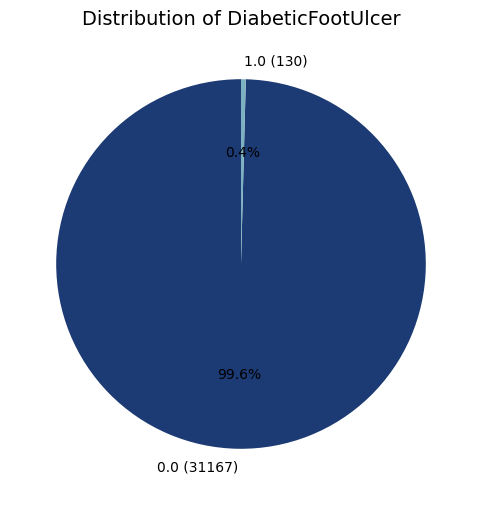

In [ ]:
#A pie chart demonstrating class imbalance in the dataset
counts = df['[DiabeticFootUlcer)'].value_counts()

# Define colors
colors = ['#1c3a73', '#7cb1c2']

# Create pie chart
plt.figure(figsize=(6, 6)) #tuple for fig size, 6x6 inches
plt.pie(
    counts, #counts for each class
    labels=[f'{cls} ({count})' for cls, count in counts.items()],  # add labels with counts... counts.items() returns an iterable of tuples
                                                                    #e.g., [('class', count)], which are then unpacked and formatted into labels
    autopct='%1.1f%%',  # Show percentages
    colors=colors,
    startangle=90
)

# Set title
plt.title('Distribution of DiabeticFootUlcer', fontsize=14)

# Show plot
plt.show()

In [ ]:
#Resetting the index
df = df.reset_index(drop=True)
df.head()

,Patient_ID,Sex,A1c,FBS,duration_b_R1_[corticosteroid]_Days,duration_b_R1_[1stlineantidiabetic]_Days,duration_b_R1_[2ndline-antidiabetic]_Days,[DiabeticFootUlcer)
0,4001000000255826,Female,6.8,4.8,NaN,NaN,NaN,0.0
1,4001000000255826,Female,7.3,7.2,NaN,NaN,NaN,0.0
2,4001000000256466,Female,7.7,7.7,NaN,NaN,NaN,0.0
3,4001000000256627,Male,6.7,5.6,NaN,NaN,NaN,0.0
4,4001000000261726,Male,7.0,6.0,NaN,NaN,NaN,0.0


In [ ]:
# Using the map() function to transform the 'Sex' column
df['Sex'] = df['Sex'].map({'Male': 0, 'Female': 1})
df

,Patient_ID,Sex,A1c,FBS,duration_b_R1_[corticosteroid]_Days,duration_b_R1_[1stlineantidiabetic]_Days,duration_b_R1_[2ndline-antidiabetic]_Days,[DiabeticFootUlcer)
0,4001000000255826,1,6.8,4.8,NaN,NaN,NaN,0.0
1,4001000000255826,1,7.3,7.2,NaN,NaN,NaN,0.0
2,4001000000256466,1,7.7,7.7,NaN,NaN,NaN,0.0
3,4001000000256627,0,6.7,5.6,NaN,NaN,NaN,0.0
4,4001000000261726,0,7.0,6.0,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...
31292,4001000000046730,1,6.4,6.6,NaN,NaN,NaN,0.0
31293,4001000000046730,1,6.3,8.1,NaN,NaN,NaN,0.0
31294,4001000000046730,1,6.5,6.9,NaN,NaN,NaN,0.0
31295,4001000000045462,1,5.9,6.0,NaN,NaN,NaN,0.0


In [ ]:
df['[DiabeticFootUlcer)'] = df['[DiabeticFootUlcer)'].astype(int)
df.dtypes

,0
Patient_ID,int64
Sex,int64
A1c,float64
FBS,float64
duration_b_R1_[corticosteroid]_Days,float64
duration_b_R1_[1stlineantidiabetic]_Days,float64
duration_b_R1_[2ndline-antidiabetic]_Days,float64
[DiabeticFootUlcer),int64


In [ ]:
print(df.shape)

(31297, 8)


Shape: (31297, 8)

Dtypes:
 Patient_ID                                     int64
Sex                                            int64
A1c                                          float64
FBS                                          float64
duration_b_R1_[corticosteroid]_Days          float64
duration_b_R1_[1stlineantidiabetic]_Days     float64
duration_b_R1_[2ndline-antidiabetic]_Days    float64
[DiabeticFootUlcer)                            int64
dtype: object

Missing values count:
 Patient_ID                                       0
Sex                                              0
A1c                                           3989
FBS                                              0
duration_b_R1_[corticosteroid]_Days          26407
duration_b_R1_[1stlineantidiabetic]_Days     23429
duration_b_R1_[2ndline-antidiabetic]_Days    28120
[DiabeticFootUlcer)                              0
dtype: int64

Missing values (%):
 Patient_ID                                    0.00
Sex             

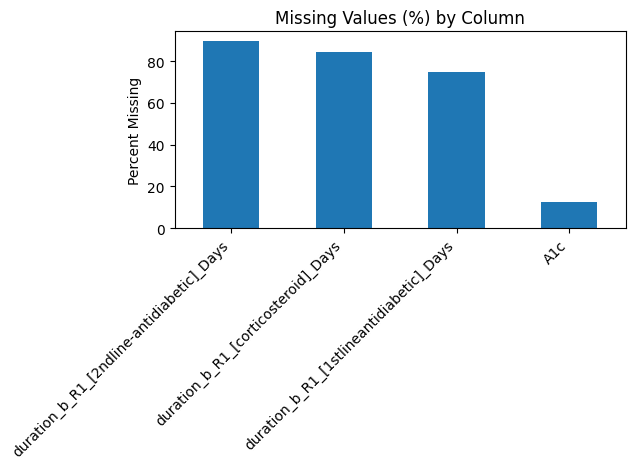

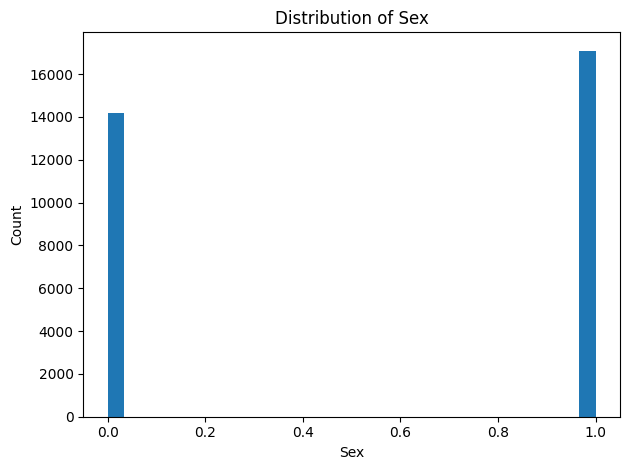

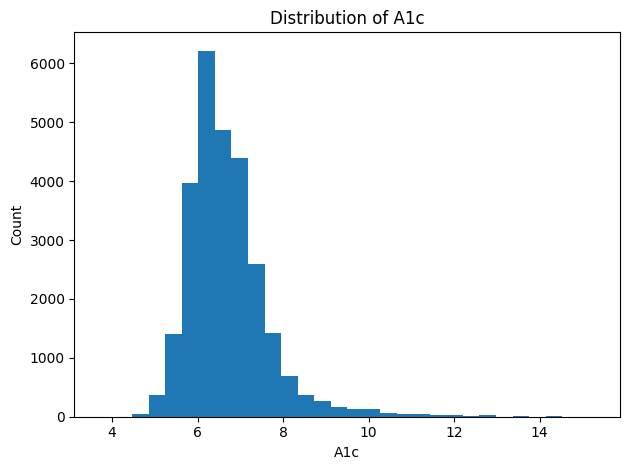

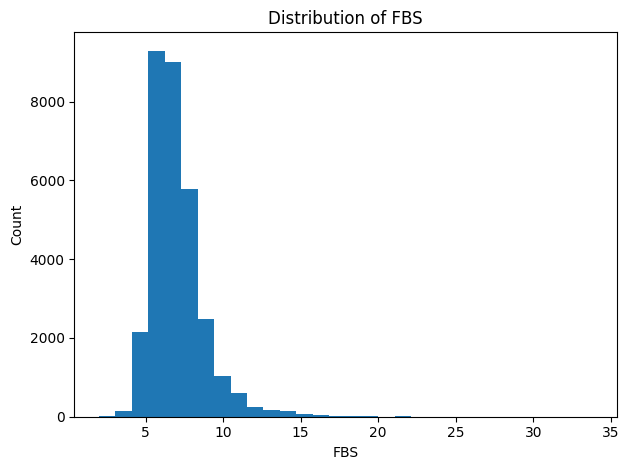

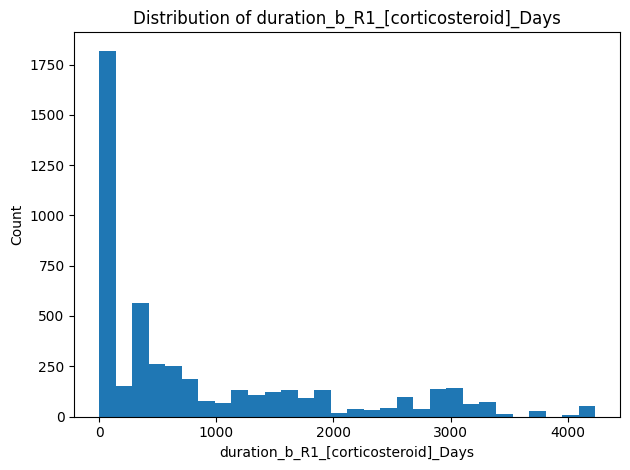

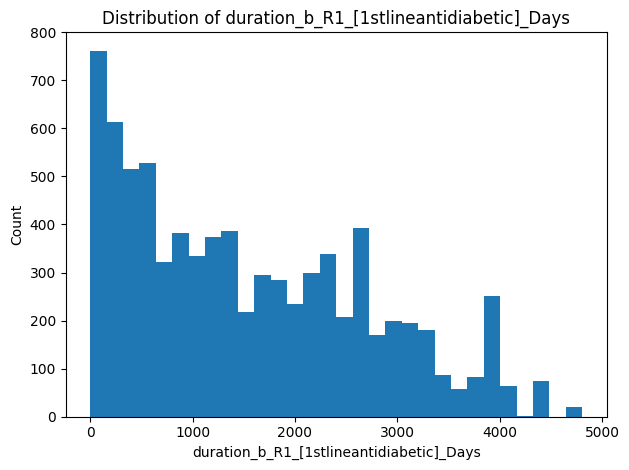

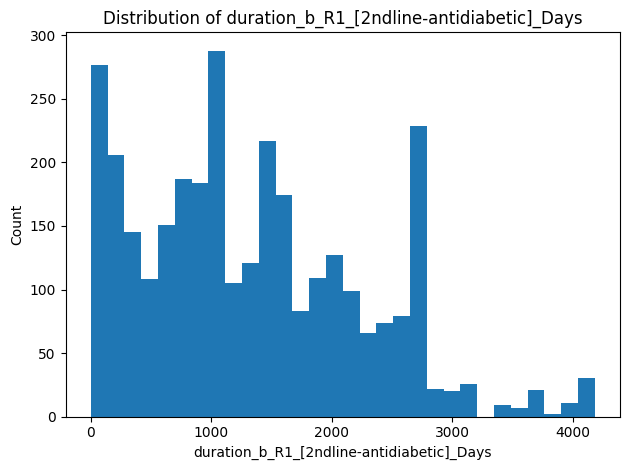

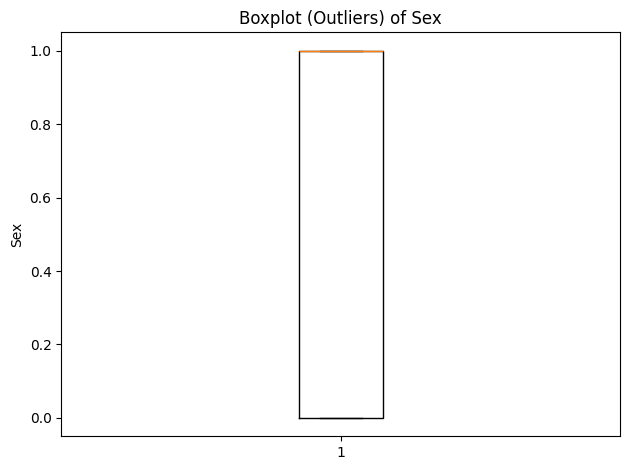

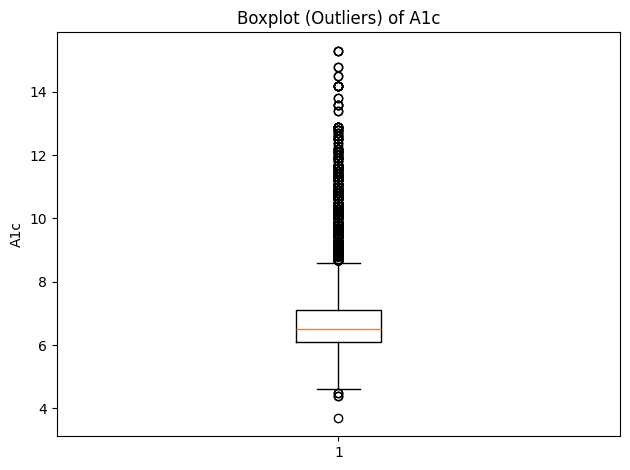

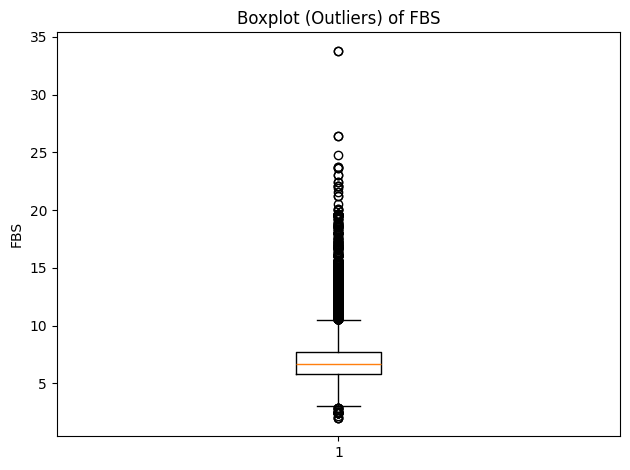

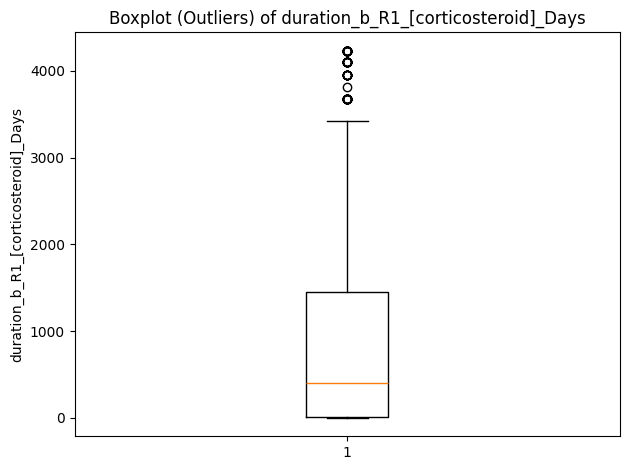

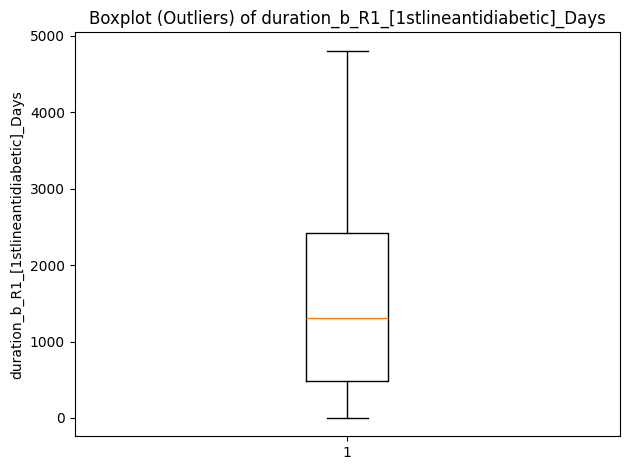

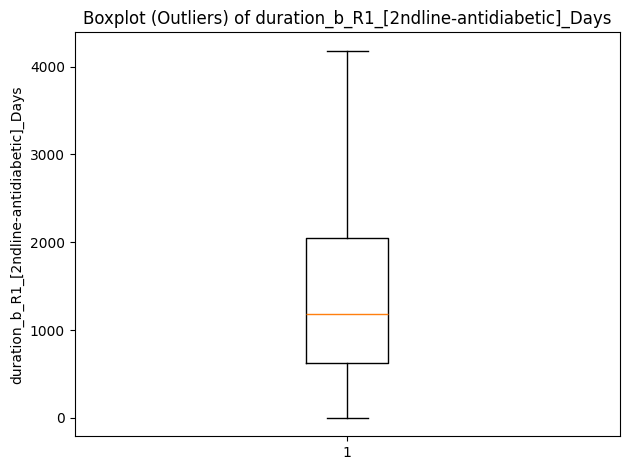


IQR-based outlier summary:
Sex: outliers=0, IQR-bounds=(-1.5, 2.5)
A1c: outliers=1038, IQR-bounds=(4.6, 8.6)
FBS: outliers=1320, IQR-bounds=(2.95, 10.6)
duration_b_R1_[corticosteroid]_Days: outliers=90, IQR-bounds=(-2.14e+03, 3.61e+03)
duration_b_R1_[1stlineantidiabetic]_Days: outliers=0, IQR-bounds=(-2.4e+03, 5.31e+03)
duration_b_R1_[2ndline-antidiabetic]_Days: outliers=0, IQR-bounds=(-1.52e+03, 4.19e+03)


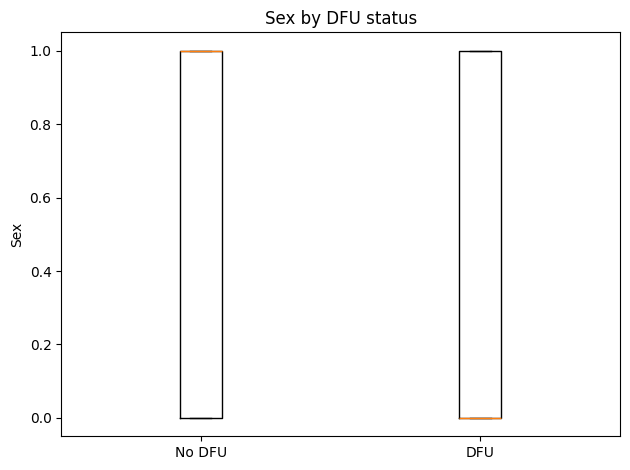

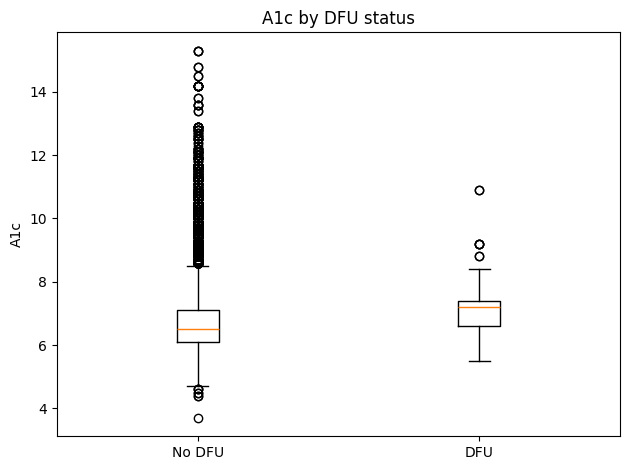

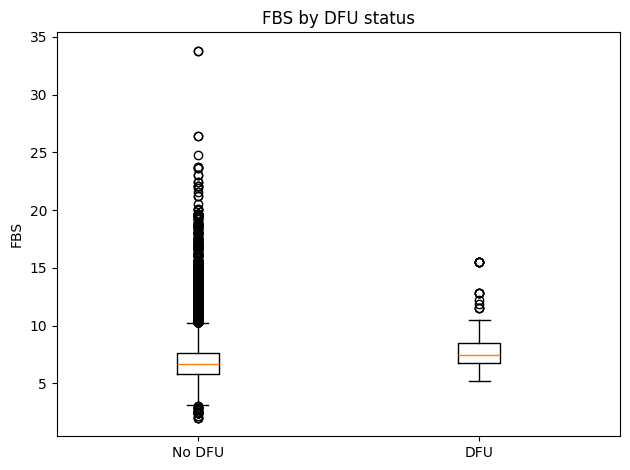

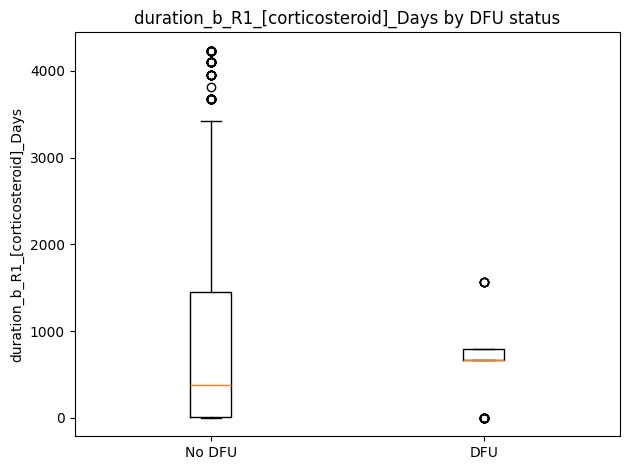

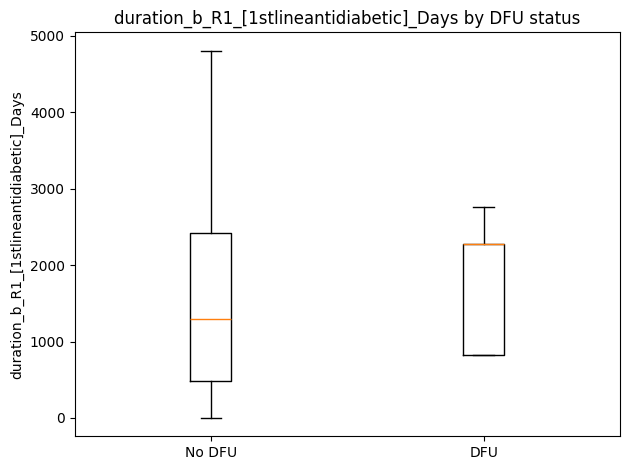

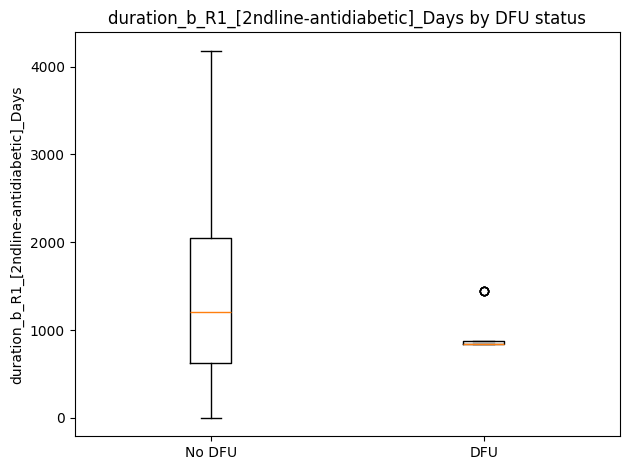

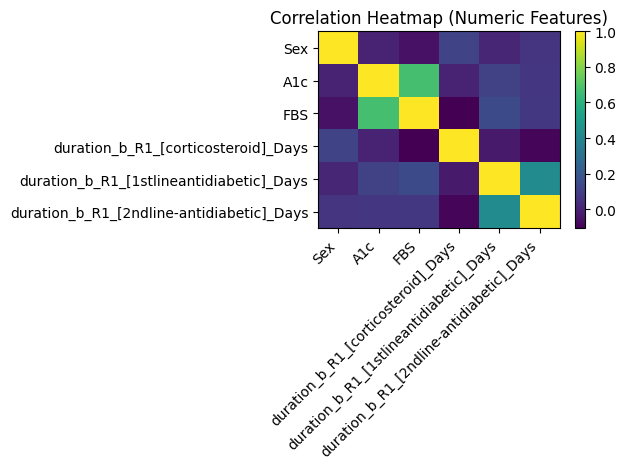


Correlation matrix:
                                             Sex    A1c    FBS  \
Sex                                        1.000  0.002 -0.054   
A1c                                        0.002  1.000  0.672   
FBS                                       -0.054  0.672  1.000   
duration_b_R1_[corticosteroid]_Days        0.121  0.000 -0.107   
duration_b_R1_[1stlineantidiabetic]_Days   0.010  0.112  0.141   
duration_b_R1_[2ndline-antidiabetic]_Days  0.066  0.070  0.074   

                                           duration_b_R1_[corticosteroid]_Days  \
Sex                                                                      0.121   
A1c                                                                      0.000   
FBS                                                                     -0.107   
duration_b_R1_[corticosteroid]_Days                                      1.000   
duration_b_R1_[1stlineantidiabetic]_Days                                -0.026   
duration_b_R1_[2ndline-a

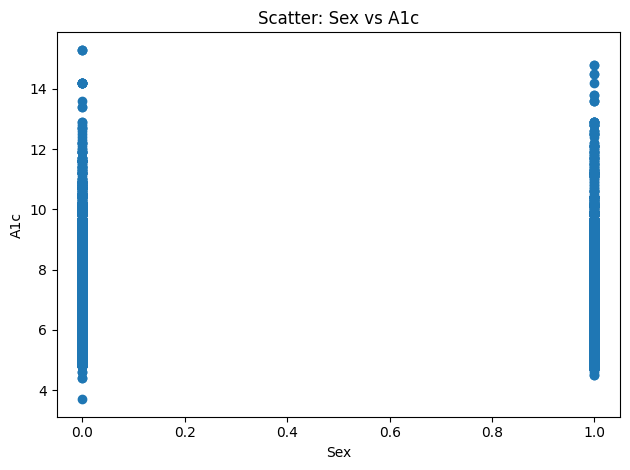

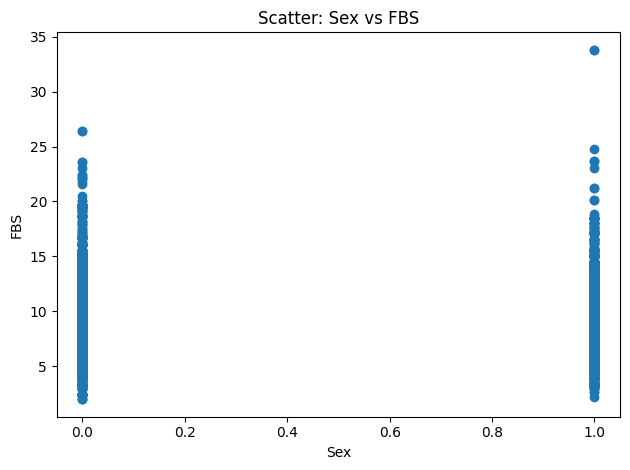

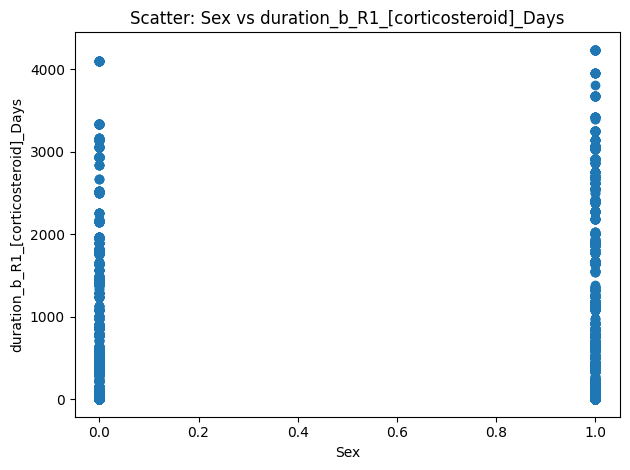

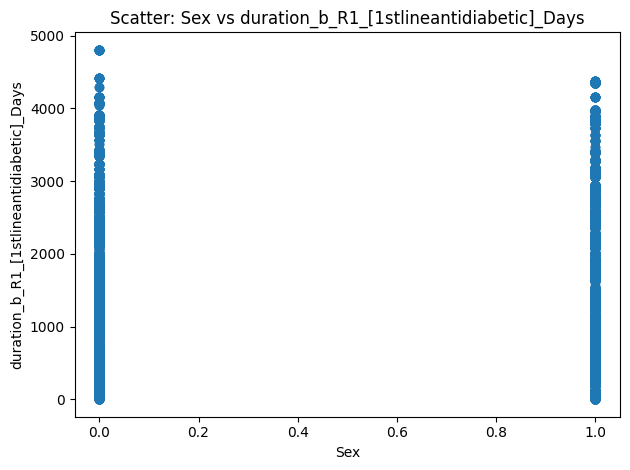

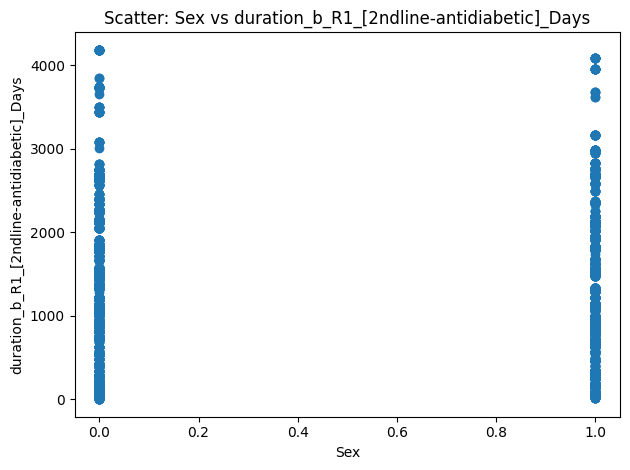

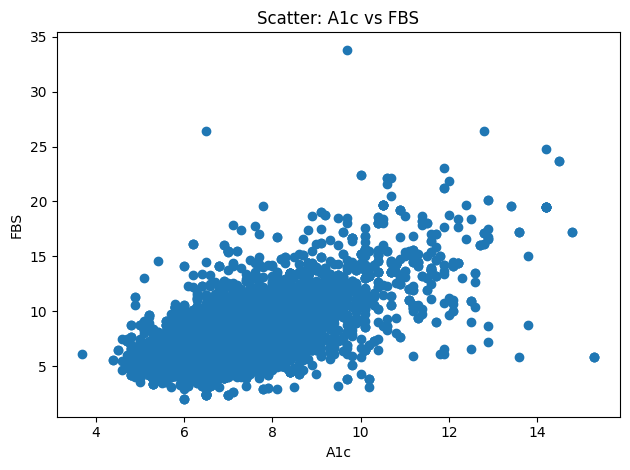

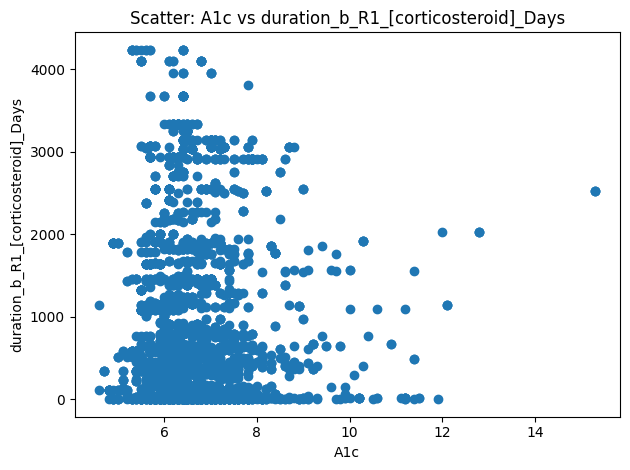

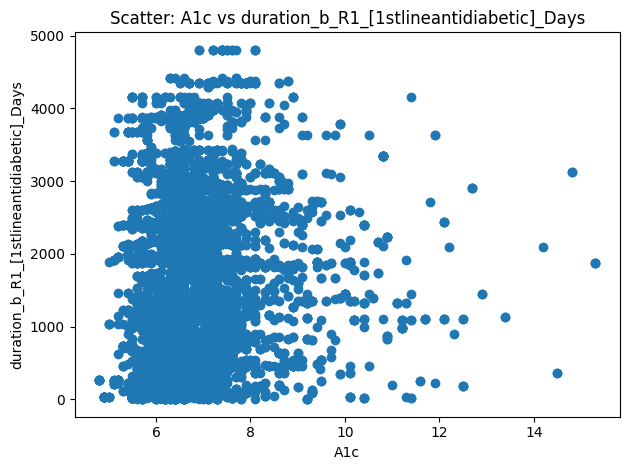

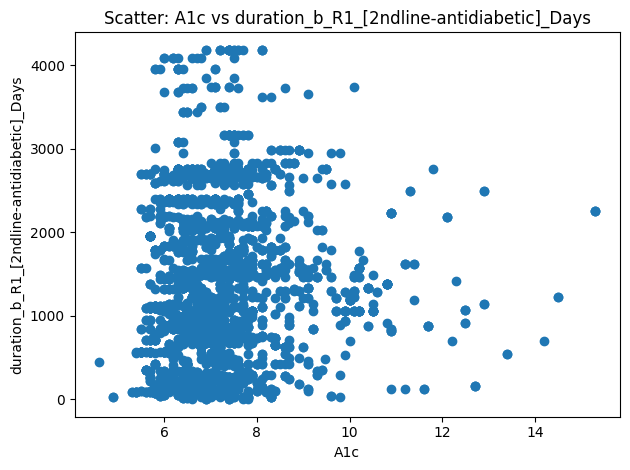

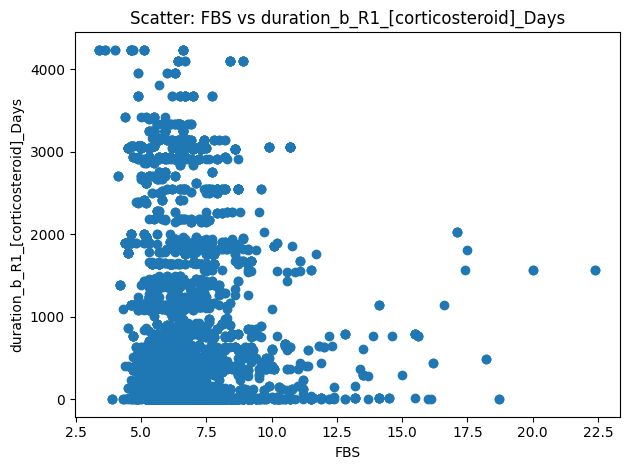

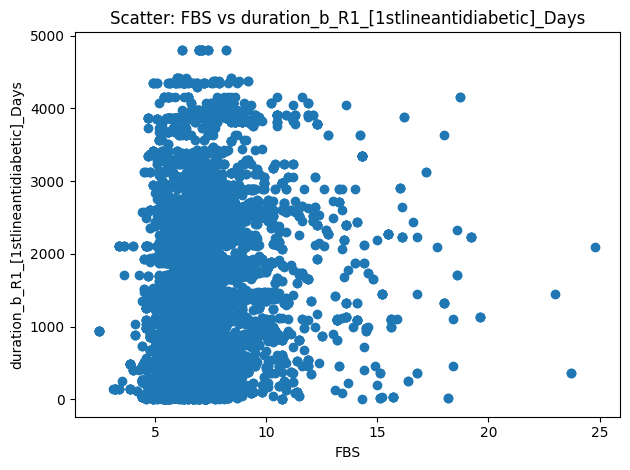

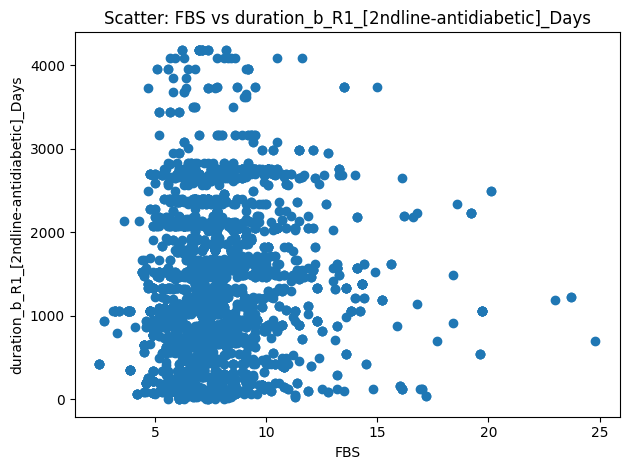

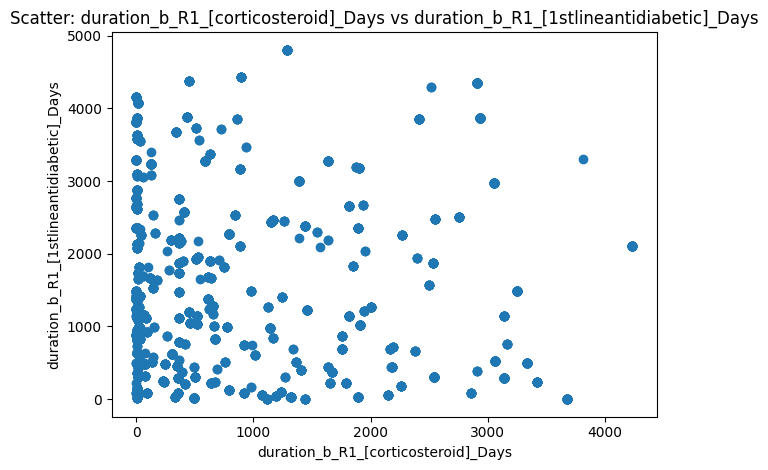

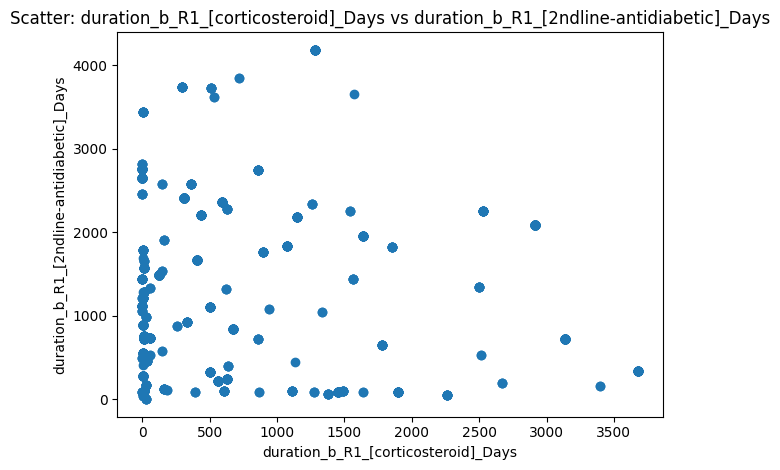

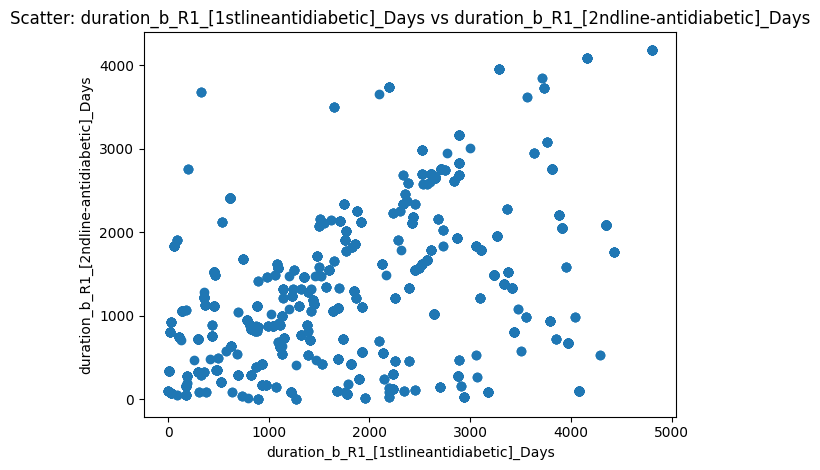

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Make sure target is clean
# -----------------------------
df = df.copy()

target_col = "[DiabeticFootUlcer)"
unneeded_cols = ["Patient_ID"]

num_cols = [c for c in df.columns if c not in [target_col] + unneeded_cols]



# -----------------------------
# 1) Basic overview
# -----------------------------
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values count:\n", df.isna().sum())
print("\nMissing values (%):\n", (df.isna().mean() * 100).round(2))

print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))
print("\nTarget distribution (%):")
print((df[target_col].value_counts(dropna=False, normalize=True) * 100).round(2))

print("\nSummary stats (numeric):")
print(df[num_cols].describe().T)

# -----------------------------
# 2) Missingness bar plot
# -----------------------------
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    plt.figure()
    missing_pct.plot(kind="bar")
    plt.title("Missing Values (%) by Column")
    plt.ylabel("Percent Missing")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No missing values found in these columns.")

# -----------------------------
# 3) Distributions + Outliers (Boxplots)
# -----------------------------
# Histograms
for col in num_cols:
    plt.figure()
    x = df[col].dropna()
    plt.hist(x, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Boxplots (outlier view)
for col in num_cols:
    plt.figure()
    x = df[col].dropna()
    plt.boxplot(x, vert=True)
    plt.title(f"Boxplot (Outliers) of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4) Outlier counts using IQR rule (numeric report)
# -----------------------------
def iqr_outlier_count(series: pd.Series):
    s = series.dropna()
    if len(s) < 4:
        return 0, np.nan, np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    outliers = ((s < lo) | (s > hi)).sum()
    return int(outliers), lo, hi

print("\nIQR-based outlier summary:")
for col in num_cols:
    out_ct, lo, hi = iqr_outlier_count(df[col])
    print(f"{col}: outliers={out_ct}, IQR-bounds=({lo:.3g}, {hi:.3g})")

# -----------------------------
# 5) DFU vs non-DFU comparison (Boxplots by class)
# -----------------------------
# (only if target has both classes)
if df[target_col].nunique(dropna=True) >= 2:
    for col in num_cols:
        plt.figure()
        # Prepare group arrays
        g0 = df.loc[df[target_col] == 0, col].dropna()
        g1 = df.loc[df[target_col] == 1, col].dropna()
        plt.boxplot([g0, g1], labels=["No DFU", "DFU"])
        plt.title(f"{col} by DFU status")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

# -----------------------------
# 6) Collinearity: Correlation matrix + Heatmap
# -----------------------------
corr = df[num_cols].corr()

plt.figure()
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

print("\nCorrelation matrix:")
print(corr.round(3))

# Show highly correlated pairs
threshold = 0.8
high_pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            high_pairs.append((cols[i], cols[j], val))

if high_pairs:
    print(f"\nHighly correlated pairs (|r| >= {threshold}):")
    for a, b, v in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{a} vs {b}: r={v:.3f}")
else:
    print(f"\n✅ No feature pairs with |r| >= {threshold} in this subset.")

# -----------------------------
# 7) Quick pairwise scatter plots (small subset only)
# -----------------------------
# Helpful to visually see relationships (and weird clusters)
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        xcol, ycol = num_cols[i], num_cols[j]
        plt.figure()
        x = df[xcol]
        y = df[ycol]
        plt.scatter(x, y)
        plt.title(f"Scatter: {xcol} vs {ycol}")
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.tight_layout()
        plt.show()


<Axes: >

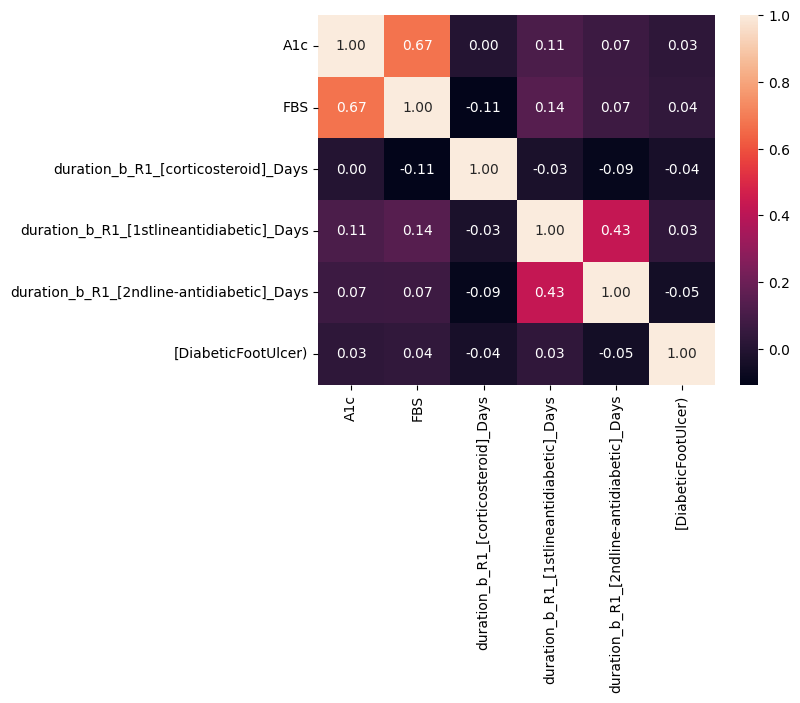

In [ ]:
# Correlation matrix to quantify relationships
corr_data = df[['A1c','FBS', 'duration_b_R1_[corticosteroid]_Days', 'duration_b_R1_[1stlineantidiabetic]_Days', 'duration_b_R1_[2ndline-antidiabetic]_Days'  ,'[DiabeticFootUlcer)']]
corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")

In [ ]:
#Replacing the Nan values; Assuming these features are Missing  At Random
duration_cols = [
    'duration_b_R1_[corticosteroid]_Days',
    'duration_b_R1_[2ndline-antidiabetic]_Days',
    'duration_b_R1_[1stlineantidiabetic]_Days'
]

df[duration_cols] = df[duration_cols].fillna(0)


Splitting the Dataset on Patient Level to Prevent Label Leakage

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Select the columns you need
# -----------------------------
cols = [
    'Patient_ID',
    'A1c',
    'FBS',
    'duration_b_R1_[corticosteroid]_Days',
    'duration_b_R1_[1stlineantidiabetic]_Days',
    'duration_b_R1_[2ndline-antidiabetic]_Days',
    '[DiabeticFootUlcer)'
]

df_sub = df[cols].copy()

# -----------------------------
# 2. Create patient-level labels
#    A patient is positive if they ever had DFU = 1
# -----------------------------
patient_level = (
    df_sub.groupby('Patient_ID')['[DiabeticFootUlcer)']
    .max()
    .reset_index()
)

# patient_level now has:
# Patient_ID | patient_outcome
# where patient_outcome = 1 if patient ever had positive visit

# -----------------------------
# 3. Split patients, stratified by patient-level outcome
# -----------------------------
train_patients, test_patients = train_test_split(
    patient_level['Patient_ID'],
    test_size=0.2,                      # change if needed
    random_state=42,
    stratify=patient_level['[DiabeticFootUlcer)']
)

# -----------------------------
# 4. Build train/test datasets using patient membership
# -----------------------------
train_df = df_sub[df_sub['Patient_ID'].isin(train_patients)].copy()
test_df  = df_sub[df_sub['Patient_ID'].isin(test_patients)].copy()

# -----------------------------
# 5. Separate X and y
# -----------------------------
target_col = '[DiabeticFootUlcer)'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# -----------------------------
# 6. Check that no patient appears in both sets
# -----------------------------
train_patient_ids = set(train_df['Patient_ID'])
test_patient_ids = set(test_df['Patient_ID'])

overlap = train_patient_ids.intersection(test_patient_ids)
print(f"Number of overlapping patients: {len(overlap)}")

# -----------------------------
# 7. Check class distribution
# -----------------------------
print("\n===== PATIENT-LEVEL DISTRIBUTION =====")
print("Train patients:")
print(patient_level[patient_level['Patient_ID'].isin(train_patients)]['[DiabeticFootUlcer)'].value_counts())

print("\nTest patients:")
print(patient_level[patient_level['Patient_ID'].isin(test_patients)]['[DiabeticFootUlcer)'].value_counts())

print("\n===== VISIT-LEVEL DISTRIBUTION =====")
print(f"Train samples: {len(train_df)}")
print(y_train.value_counts())

print(f"\nTest samples: {len(test_df)}")
print(y_test.value_counts())

Number of overlapping patients: 0

===== PATIENT-LEVEL DISTRIBUTION =====
Train patients:
[DiabeticFootUlcer)
0    2202
1       6
Name: count, dtype: int64

Test patients:
[DiabeticFootUlcer)
0    551
1      2
Name: count, dtype: int64

===== VISIT-LEVEL DISTRIBUTION =====
Train samples: 24739
[DiabeticFootUlcer)
0    24638
1      101
Name: count, dtype: int64

Test samples: 6558
[DiabeticFootUlcer)
0    6529
1      29
Name: count, dtype: int64


## CROSS VALIDATION ON LOGISTIC REGRESSION

# New Section


Strategy: 1_no_resampling
Best CV Score: 0.04034531859740803
Best Params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Test ROC AUC: 0.8303537004663544

Test classification report:

              precision    recall  f1-score   support

           0     0.9967    0.8301    0.9058      6529
           1     0.0098    0.3793    0.0191        29

    accuracy                         0.8281      6558
   macro avg     0.5033    0.6047    0.4625      6558
weighted avg     0.9923    0.8281    0.9019      6558


Strategy: 2_oversample_minority
Best CV Score: 0.039655807411651214
Best Params: {'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Test ROC AUC: 0.825706001341495

Test classification report:

              precision    recall  f1-score   support

           0     0.9967    0.8265    0.9036      6529
           1     0.0096    0.3793    0.0188        29

    accuracy             

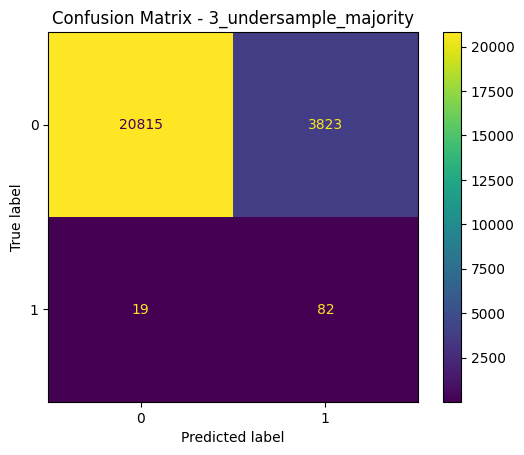

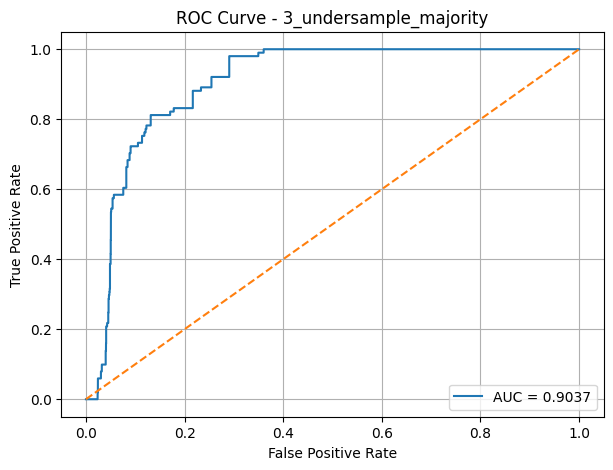


Final Test Classification Report (Best Overall Model):

              precision    recall  f1-score   support

           0     1.0000    0.8066    0.8929      6529
           1     0.0224    1.0000    0.0439        29

    accuracy                         0.8074      6558
   macro avg     0.5112    0.9033    0.4684      6558
weighted avg     0.9957    0.8074    0.8892      6558



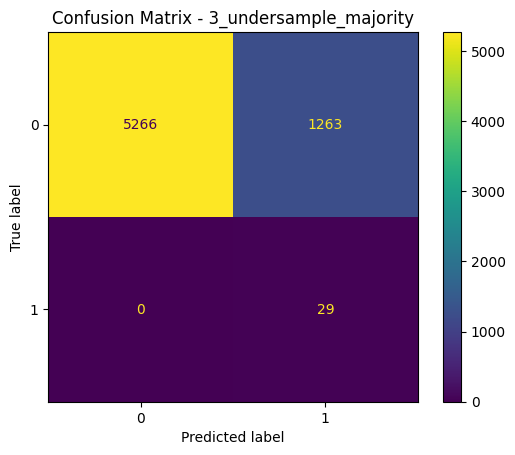

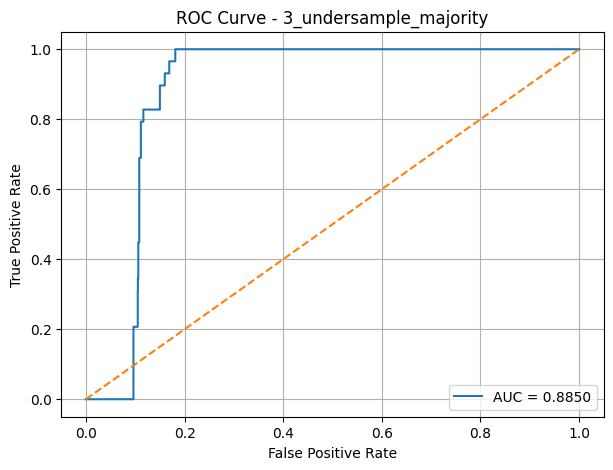

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# imblearn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN



# -----------------------------
# 1) CV setup
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 2) Shared hyperparameter grid
# -----------------------------
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__class_weight": [None, "balanced"],
}


# 3) Define strategies
strategies = {
    "1_no_resampling": None,
    "2_oversample_minority": RandomOverSampler(random_state=42),
    "3_undersample_majority": RandomUnderSampler(random_state=42),
    "4_over_and_under_combined": SMOTEENN(random_state=42),
}

results = {}
best_overall_score = -np.inf
best_overall_name = None
best_overall_model = None
best_overall_params = None


# 4) Run CV for each strategy
for name, sampler in strategies.items():
    steps = [
        ("imputer", IterativeImputer(random_state=42)),
        ("scaler", StandardScaler()),
    ]

    if sampler is not None:
        steps.append(("sampler", sampler))

    steps.append(("model", LogisticRegression(max_iter=5000)))

    pipeline = ImbPipeline(steps=steps)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=skf,
        scoring="f1",   # can change to "recall" if that matters more
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # For ROC
    y_prob = best_model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)

    results[name] = {
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "best_model": best_model,
        "test_report": classification_report(y_test, y_pred, digits=4),
        "test_auc": auc_score
    }

    # Track overall best model based on CV performance
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_name = name
        best_overall_model = best_model
        best_overall_params = grid.best_params_


# 5) Print all strategy results
for name, info in results.items():
    print("\n" + "=" * 70)
    print(f"Strategy: {name}")
    print("Best CV Score:", info["best_cv_score"])
    print("Best Params:", info["best_params"])
    print("Test ROC AUC:", info["test_auc"])
    print("\nTest classification report:\n")
    print(info["test_report"])


# 6) Best overall model
print("\n" + "=" * 70)
print("BEST OVERALL STRATEGY:", best_overall_name)
print("BEST OVERALL CV SCORE:", best_overall_score)
print("BEST OVERALL PARAMS:", best_overall_params)


# 7) Evaluate best overall model on Train set to check for overfitting
ytrain_pred_best = best_overall_model.predict(X_train)
ytrain_prob_best = best_overall_model.predict_proba(X_train)[:, 1]

print("\nFinal Test Classification Report (Best Overall Model):\n")
print(classification_report(y_train, ytrain_pred_best, digits=4))


# 8) Confusion Matrix for Train
cm = confusion_matrix(y_train, ytrain_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='d')
plt.title(f"Confusion Matrix - {best_overall_name}")
plt.show()


# 9) ROC Curve for Train
fpr, tpr, thresholds = roc_curve(y_train, ytrain_prob_best)
auc_best = roc_auc_score(y_train, ytrain_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_best:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_overall_name}")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



y_pred_best = best_overall_model.predict(X_test)
y_prob_best = best_overall_model.predict_proba(X_test)[:, 1]

print("\nFinal Test Classification Report (Best Overall Model):\n")
print(classification_report(y_test, y_pred_best, digits=4))


# 10) Confusion Matrix for Test
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='d')
plt.title(f"Confusion Matrix - {best_overall_name}")
plt.show()


# 11) ROC Curve for Test
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
auc_best = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_best:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_overall_name}")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

NEW CODE

# GAUSSIAN NAIVE BAYES


Strategy: 1_no_resampling
Best CV F1: 0.0
Best Params: {'model__var_smoothing': np.float64(1e-12)}

Confusion Matrix:
[[6529    0]
 [  29    0]]
TN=6529, FP=0, FN=29, TP=0

Test classification report:

              precision    recall  f1-score   support

           0     0.9956    1.0000    0.9978      6529
           1     0.0000    0.0000    0.0000        29

    accuracy                         0.9956      6558
   macro avg     0.4978    0.5000    0.4989      6558
weighted avg     0.9912    0.9956    0.9934      6558

Test ROC-AUC: 0.9625


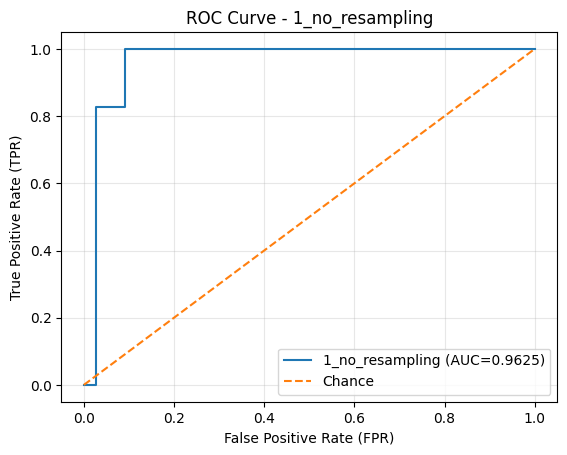


Strategy: 2_oversample_minority
Best CV F1: 0.9309523809523809
Best Params: {'model__var_smoothing': np.float64(1e-12)}

Confusion Matrix:
[[4619 1910]
 [   0   29]]
TN=4619, FP=1910, FN=0, TP=29

Test classification report:

              precision    recall  f1-score   support

           0     1.0000    0.7075    0.8287      6529
           1     0.0150    1.0000    0.0295        29

    accuracy                         0.7088      6558
   macro avg     0.5075    0.8537    0.4291      6558
weighted avg     0.9956    0.7088    0.8251      6558

Test ROC-AUC: 0.9625


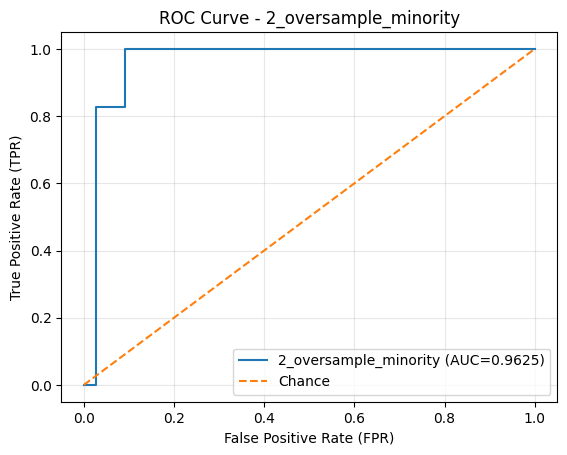


Strategy: 3_undersample_majority
Best CV F1: 0.9309523809523809
Best Params: {'model__var_smoothing': np.float64(1e-12)}

Confusion Matrix:
[[4619 1910]
 [   0   29]]
TN=4619, FP=1910, FN=0, TP=29

Test classification report:

              precision    recall  f1-score   support

           0     1.0000    0.7075    0.8287      6529
           1     0.0150    1.0000    0.0295        29

    accuracy                         0.7088      6558
   macro avg     0.5075    0.8537    0.4291      6558
weighted avg     0.9956    0.7088    0.8251      6558

Test ROC-AUC: 0.9625


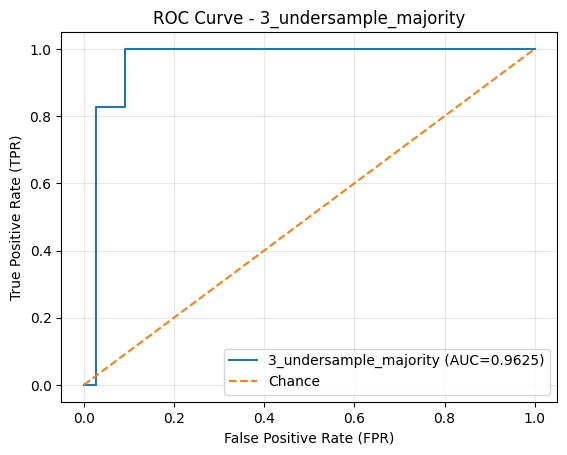


Strategy: 4_over_and_under_combined
Best CV F1: 0.9309523809523809
Best Params: {'model__var_smoothing': np.float64(1e-12)}

Confusion Matrix:
[[4619 1910]
 [   0   29]]
TN=4619, FP=1910, FN=0, TP=29

Test classification report:

              precision    recall  f1-score   support

           0     1.0000    0.7075    0.8287      6529
           1     0.0150    1.0000    0.0295        29

    accuracy                         0.7088      6558
   macro avg     0.5075    0.8537    0.4291      6558
weighted avg     0.9956    0.7088    0.8251      6558

Test ROC-AUC: 0.9625


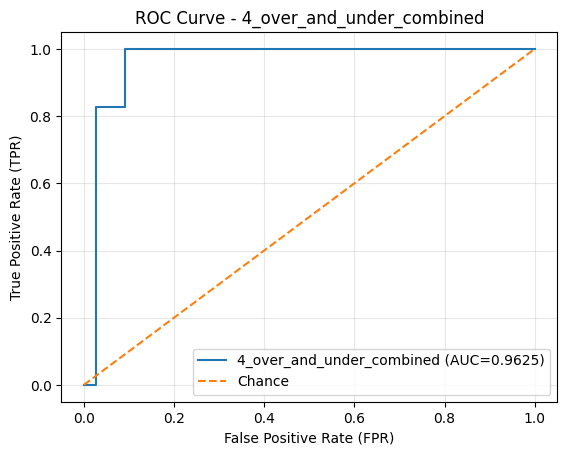

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN


# =========================================================
# Assumes you already have:
# X_train, X_test, y_train, y_test from train_test_split(...)
# =========================================================


# -----------------------------
# CV setup
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# GaussianNB hyperparameter grid
# -----------------------------
# var_smoothing adds a small value to variances for numerical stability.
# Tuning it can materially affect performance on some datasets.
param_grid = {
    "model__var_smoothing": np.logspace(-12, -6, 13)  # 1e-12 ... 1e-6
}

# -----------------------------
# Strategies (samplers)
# -----------------------------
strategies = {
    "1_no_resampling": None,
    "2_oversample_minority": RandomOverSampler(random_state=42),  # or SMOTE(random_state=42)
    "3_undersample_majority": RandomUnderSampler(random_state=42),
    "4_over_and_under_combined": SMOTEENN(random_state=42),       # combined
}

results = {}

# -----------------------------
# Run GridSearch for each strategy
# -----------------------------
for name, sampler in strategies.items():
    steps = [
        ("imputer", IterativeImputer(random_state=42)),
        # GaussianNB usually doesn't need scaling; keep pipeline simple.
        # If you want scaling, add: ("scaler", StandardScaler()),
    ]

    if sampler is not None:
        steps.append(("sampler", sampler))

    steps.append(("model", GaussianNB()))

    pipeline = ImbPipeline(steps=steps)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=skf,
        scoring="recall",   # for extreme imbalance, consider "average_precision" too
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # ---- Test predictions
    y_pred = best_model.predict(X_test)

    # GaussianNB supports predict_proba -> use for ROC/AUC
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # ---- Metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results[name] = {
        "best_params": grid.best_params_,
        "best_cv_f1": grid.best_score_,
        "confusion_matrix": cm,
        "tn_fp_fn_tp": (tn, fp, fn, tp),
        "test_report": classification_report(y_test, y_pred, digits=4),
        "auc": auc,
        "roc": (fpr, tpr),
    }

# -----------------------------
# Print + Plot
# -----------------------------
for name, info in results.items():
    print("\n" + "=" * 75)
    print(f"Strategy: {name}")
    print(f"Best CV F1: {info['best_cv_f1']}")
    print(f"Best Params: {info['best_params']}")

    cm = info["confusion_matrix"]
    tn, fp, fn, tp = info["tn_fp_fn_tp"]
    print("\nConfusion Matrix:")
    print(cm)
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    print("\nTest classification report:\n")
    print(info["test_report"])

    print(f"Test ROC-AUC: {info['auc']:.4f}")

    fpr, tpr = info["roc"]
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC={info['auc']:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



TRAIN RESULTS
TN=22740, FP=2805, FN=35, TP=89
ROC-AUC: 0.8762

              precision    recall  f1-score   support

           0     0.9985    0.8902    0.9412     25545
           1     0.0308    0.7177    0.0590       124

    accuracy                         0.8894     25669
   macro avg     0.5146    0.8040    0.5001     25669
weighted avg     0.9938    0.8894    0.9370     25669



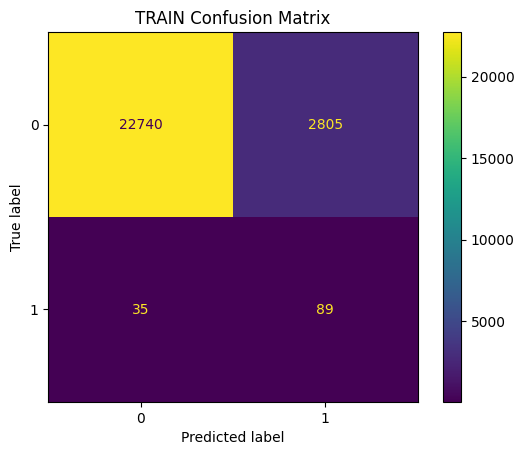


TEST RESULTS
TN=4868, FP=754, FN=6, TP=0
ROC-AUC: 0.8144

              precision    recall  f1-score   support

           0     0.9988    0.8659    0.9276      5622
           1     0.0000    0.0000    0.0000         6

    accuracy                         0.8650      5628
   macro avg     0.4994    0.4329    0.4638      5628
weighted avg     0.9977    0.8650    0.9266      5628



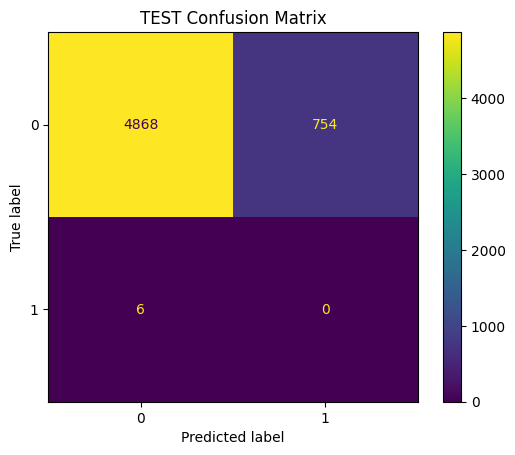

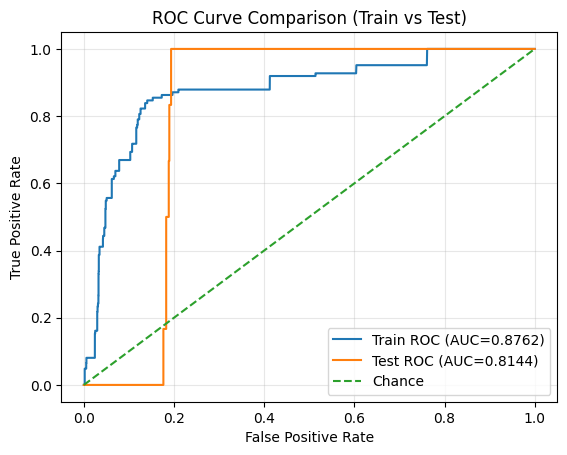

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN


# ============================================
# Best model from CV (Strategy 4)
# ============================================
final_model = ImbPipeline(steps=[
    ("imputer", IterativeImputer(random_state=42)),
    ("sampler", SMOTEENN(random_state=42)),
    ("model", GaussianNB(var_smoothing=1e-6))
])


# ============================================
# Fit on TRAIN
# ============================================
final_model.fit(X_train, y_train)


# ============================================
# Function to evaluate split
# ============================================
def evaluate_split(name, X, y, model):

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    auc = roc_auc_score(y, y_prob)

    print("\n" + "="*70)
    print(f"{name} RESULTS")
    print("="*70)
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"ROC-AUC: {auc:.4f}\n")
    print(classification_report(y, y_pred, digits=4))

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return auc


# ============================================
# Evaluate TRAIN and TEST
# ============================================
auc_train = evaluate_split("TRAIN", X_train, y_train, final_model)
auc_test  = evaluate_split("TEST",  X_test,  y_test,  final_model)


# ============================================
# Compare ROC Curves
# ============================================
y_prob_train = final_model.predict_proba(X_train)[:,1]
y_prob_test  = final_model.predict_proba(X_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train, y_prob_train)
fpr_te, tpr_te, _ = roc_curve(y_test, y_prob_test)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_train:.4f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_test:.4f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Train vs Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
